In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    precision_recall_curve,
    auc,
)

In [2]:
def resolve_data_path(filename: str) -> str:
    candidates = [
        Path(filename),
        Path.cwd() / filename,
        Path("/mnt/data") / filename,
        Path("/content") / filename,
    ]
    for p in candidates:
        if p.exists():
            return str(p)
    return filename

DATA_FILE = "global_house_purchase_dataset.csv"
DATA_PATH = resolve_data_path(DATA_FILE)
DATA_PATH

'global_house_purchase_dataset.csv'

In [3]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (200000, 25)


,property_id,country,city,property_type,furnishing_status,property_size_sqft,price,constructed_year,previous_owners,rooms,...,customer_salary,loan_amount,loan_tenure_years,monthly_expenses,down_payment,emi_to_income_ratio,satisfaction_score,neighbourhood_rating,connectivity_score,decision
0,1,France,Marseille,Farmhouse,Semi-Furnished,991,412935,1989,6,6,...,10745,193949,15,6545,218986,0.16,1,5,6,0
1,2,South Africa,Cape Town,Apartment,Semi-Furnished,1244,224538,1990,4,8,...,16970,181465,20,8605,43073,0.08,9,1,2,0
2,3,South Africa,Johannesburg,Farmhouse,Semi-Furnished,4152,745104,2019,5,2,...,21914,307953,30,2510,437151,0.09,6,8,1,0
3,4,Germany,Frankfurt,Farmhouse,Semi-Furnished,3714,1110959,2008,1,3,...,17980,674720,15,8805,436239,0.33,2,6,6,0
4,5,South Africa,Johannesburg,Townhouse,Fully-Furnished,531,99041,2007,6,3,...,17676,65833,25,8965,33208,0.03,3,3,4,0


In [4]:
print("==== INFO ====")
display(df.info())

print("\n==== MISSING (TOP) ====")
missing = df.isnull().sum().sort_values(ascending=False)
display(missing[missing > 0].head(20))

print("\nDuplicate rows:", int(df.duplicated().sum()))

print("\n==== TARGET DISTRIBUTION (decision) ====")
display(df["decision"].value_counts())
display((df["decision"].value_counts(normalize=True) * 100).round(2).rename("%"))

==== INFO ====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   property_id              200000 non-null  int64  
 1   country                  200000 non-null  object 
 2   city                     200000 non-null  object 
 3   property_type            200000 non-null  object 
 4   furnishing_status        200000 non-null  object 
 5   property_size_sqft       200000 non-null  int64  
 6   price                    200000 non-null  int64  
 7   constructed_year         200000 non-null  int64  
 8   previous_owners          200000 non-null  int64  
 9   rooms                    200000 non-null  int64  
 10  bathrooms                200000 non-null  int64  
 11  garage                   200000 non-null  int64  
 12  garden                   200000 non-null  int64  
 13  crime_cases_reported     200000 non-null  in

None


==== MISSING (TOP) ====


,0



Duplicate rows: 0

==== TARGET DISTRIBUTION (decision) ====


,count
decision,
0,153932
1,46068


,%
decision,
0,76.97
1,23.03


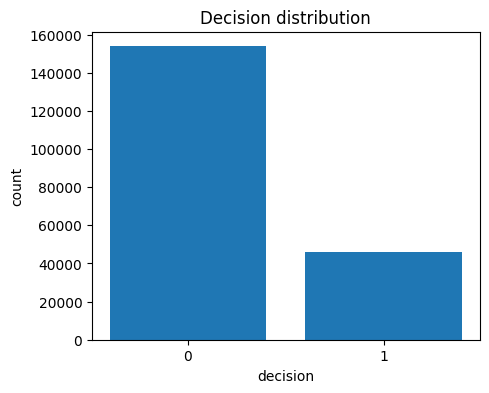

In [5]:
# EDA: phân bố target
counts = df["decision"].value_counts().sort_index()
plt.figure(figsize=(5,4))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Decision distribution")
plt.xlabel("decision")
plt.ylabel("count")
plt.show()

In [6]:
# EDA: thống kê nhanh numeric
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
display(df[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
property_id,200000.0,1.000005e+05,57735.171256,1.0,50000.75,100000.50,150000.25,200000.00
property_size_sqft,200000.0,3.195633e+03,1613.322287,400.0,1802.00,3190.00,4589.00,6000.00
price,200000.0,1.215365e+06,823663.258915,56288.0,565989.50,1023429.00,1725556.50,4202732.00
constructed_year,200000.0,1.991488e+03,18.494064,1960.0,1975.00,1991.00,2008.00,2023.00
previous_owners,200000.0,3.001370e+00,2.002198,0.0,1.00,3.00,5.00,6.00
rooms,200000.0,4.513855e+00,2.295669,1.0,3.00,5.00,7.00,8.00
bathrooms,200000.0,2.760030e+00,1.840959,1.0,1.00,2.00,4.00,8.00
garage,200000.0,4.993500e-01,0.500001,0.0,0.00,0.00,1.00,1.00
garden,200000.0,5.002150e-01,0.500001,0.0,0.00,1.00,1.00,1.00
crime_cases_reported,200000.0,1.229065e+00,1.185336,0.0,0.00,1.00,2.00,10.00


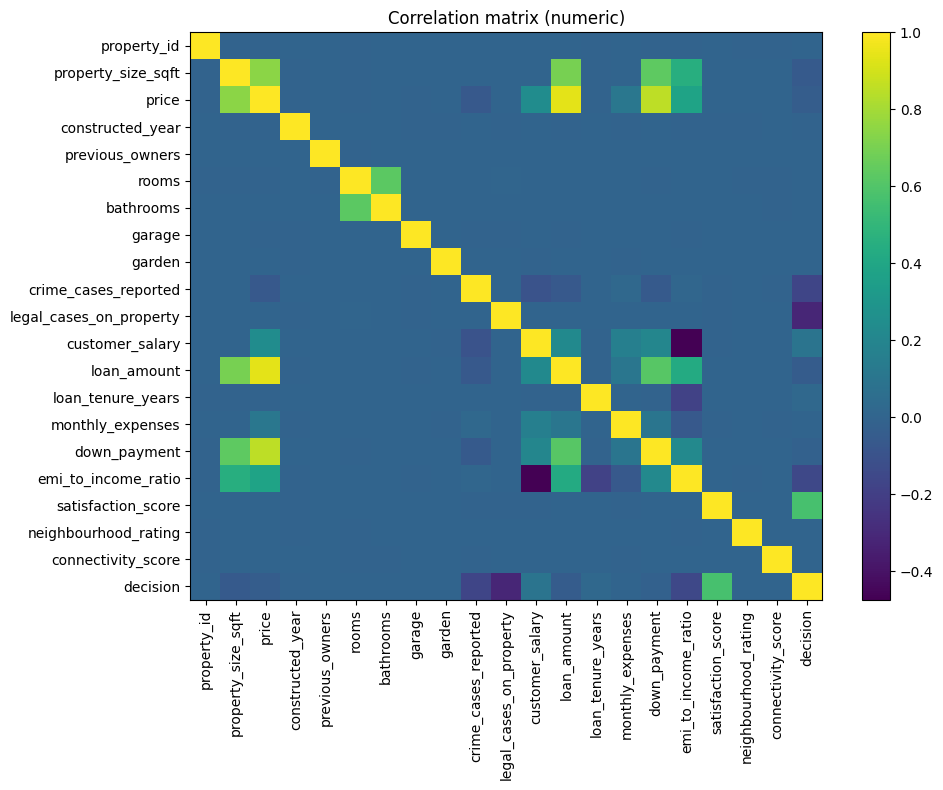

In [7]:
# EDA: correlation (numeric only)
corr = df[numeric_cols].corr(numeric_only=True)
plt.figure(figsize=(10,8))
plt.imshow(corr, aspect="auto")
plt.title("Correlation matrix (numeric)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar()
plt.tight_layout()
plt.show()

In [8]:
# 1) Chuẩn bị X/y
TARGET = "decision"

X = df.drop(columns=[TARGET], errors="ignore").copy()
y = df[TARGET].copy()

# Loại bỏ cột định danh nếu có
X = X.drop(columns=["property_id"], errors="ignore")

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

print("Categorical cols:", cat_cols)
print("Numeric cols:", num_cols)
print("X shape:", X.shape, "| y shape:", y.shape)

Categorical cols: ['country', 'city', 'property_type', 'furnishing_status']
Numeric cols: ['property_size_sqft', 'price', 'constructed_year', 'previous_owners', 'rooms', 'bathrooms', 'garage', 'garden', 'crime_cases_reported', 'legal_cases_on_property', 'customer_salary', 'loan_amount', 'loan_tenure_years', 'monthly_expenses', 'down_payment', 'emi_to_income_ratio', 'satisfaction_score', 'neighbourhood_rating', 'connectivity_score']
X shape: (200000, 23) | y shape: (200000,)


In [9]:
# 2) Train/Test split (stratify để giữ tỷ lệ lớp)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (160000, 23) (160000,)
Test : (40000, 23) (40000,)


In [10]:
# 3) Pipeline tiền xử lý + model
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop",
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
)

pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("rf", rf),
])

pipe

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['property_size_sqft',
                                                   'price', 'constructed_year',
                                                   'previous_owners', 'rooms',
                                                   'bathrooms', 'garage',
                                                   'garden',
                                                   'crime_cases_reported',
                                                   'legal_cases_on_property',
                                                   'customer_salary',
                                                   'loan_amount',
                                                   'loan_tenure_years',
                                                   'monthly_expenses'...
                                                   'satisfaction_score',
                                                   'neighbourhood_rating',
                                                   'connectivity_score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['country', 'city',
                                                   'property_type',
                                                   'furnishing_status'])])),
                ('rf',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [11]:
# 4) Train
pipe.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['property_size_sqft',
                                                   'price', 'constructed_year',
                                                   'previous_owners', 'rooms',
                                                   'bathrooms', 'garage',
                                                   'garden',
                                                   'crime_cases_reported',
                                                   'legal_cases_on_property',
                                                   'customer_salary',
                                                   'loan_amount',
                                                   'loan_tenure_years',
                                                   'monthly_expenses'...
                                                   'satisfaction_score',
                                                   'neighbourhood_rating',
                                                   'connectivity_score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['country', 'city',
                                                   'property_type',
                                                   'furnishing_status'])])),
                ('rf',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     30786
           1     1.0000    1.0000    1.0000      9214

    accuracy                         1.0000     40000
   macro avg     1.0000    1.0000    1.0000     40000
weighted avg     1.0000    1.0000    1.0000     40000



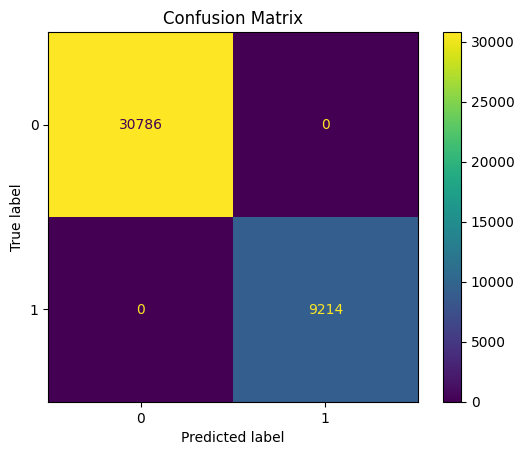

ROC-AUC: 1.0


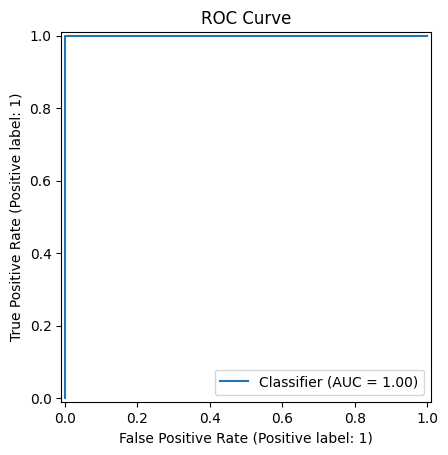

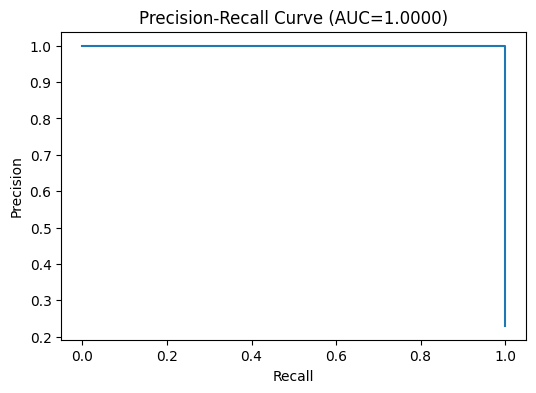

In [12]:
# 5) Evaluate
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", round(float(roc_auc), 6))

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve")
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.title(f"Precision-Recall Curve (AUC={pr_auc:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

## Feature importance (Top 20)

Vì dùng OneHotEncoder nên số feature sau tiền xử lý sẽ tăng lên. Cell dưới sẽ lấy đúng tên feature sau OneHot và vẽ top 20.

,feature,importance
16,satisfaction_score,0.595086
9,legal_cases_on_property,0.174744
8,crime_cases_reported,0.084492
15,emi_to_income_ratio,0.059463
10,customer_salary,0.016700
11,loan_amount,0.008714
1,price,0.007117
0,property_size_sqft,0.006839
14,down_payment,0.005662
13,monthly_expenses,0.005394


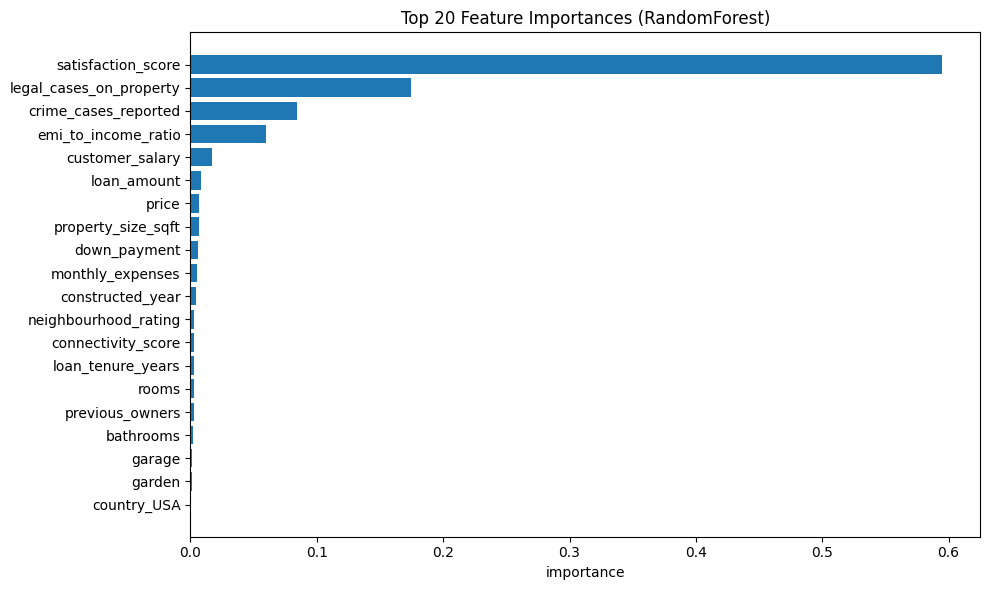

In [13]:
# Lấy tên feature sau OneHotEncoder
ohe = pipe.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(cat_cols) if len(cat_cols) else np.array([])
feature_names = np.r_[num_cols, cat_feature_names]

importances = pipe.named_steps["rf"].feature_importances_
fi = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values(
    "importance", ascending=False
)

display(fi.head(30))

top = fi.head(20).iloc[::-1]
plt.figure(figsize=(10,6))
plt.barh(top["feature"], top["importance"])
plt.title("Top 20 Feature Importances (RandomForest)")
plt.xlabel("importance")
plt.tight_layout()
plt.show()

## Hyperparameter tuning nhanh

Dataset khá lớn (200k dòng). Cell dưới sẽ **lấy sample** để chạy RandomizedSearchCV nhanh hơn. Nếu bạn có máy mạnh có thể tăng `SAMPLE_FOR_TUNING` / `n_iter`.

In [14]:
from sklearn.model_selection import RandomizedSearchCV

SAMPLE_FOR_TUNING = 30000
if len(X_train) > SAMPLE_FOR_TUNING:
    X_tune = X_train.sample(SAMPLE_FOR_TUNING, random_state=42)
    y_tune = y_train.loc[X_tune.index]
else:
    X_tune, y_tune = X_train, y_train

param_dist = {
    "rf__n_estimators": [200, 300, 500],
    "rf__max_depth": [None, 8, 12, 18, 25],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4],
    "rf__max_features": ["sqrt", "log2", None],
}

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=15,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_tune, y_tune)
print("Best ROC-AUC (CV):", search.best_score_)
print("Best params:", search.best_params_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best ROC-AUC (CV): 1.0
Best params: {'rf__n_estimators': 300, 'rf__min_samples_split': 10, 'rf__min_samples_leaf': 2, 'rf__max_features': None, 'rf__max_depth': None}


In [15]:
# Nếu muốn dùng model tốt nhất từ tuning:
# best_pipe = search.best_estimator_
# best_pipe.fit(X_train, y_train)
# y_proba_best = best_pipe.predict_proba(X_test)[:, 1]
# print("Test ROC-AUC:", roc_auc_score(y_test, y_proba_best))

## Lưu model pipeline

Lưu cả preprocess + model để dùng dự đoán sau này.

In [16]:
import joblib

MODEL_PATH = "house_purchase_rf_pipeline.joblib"
joblib.dump(pipe, MODEL_PATH)
MODEL_PATH

'house_purchase_rf_pipeline.joblib'

In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Accuracy: 1.0
[[30786     0]
 [    0  9214]]


In [18]:
for rs in [1, 7, 13, 42, 99]:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=rs, stratify=y
    )
    pipe.fit(X_train, y_train)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    print(rs, roc_auc_score(y_test, y_proba))


1 1.0
7 1.0
13 1.0
42 1.0
99 1.0


In [19]:
y_train_shuf = y_train.sample(frac=1, random_state=42).reset_index(drop=True)
X_train_shuf = X_train.reset_index(drop=True)

pipe.fit(X_train_shuf, y_train_shuf)
y_proba_shuf = pipe.predict_proba(X_test)[:, 1]
print("AUC after label shuffle:", roc_auc_score(y_test, y_proba_shuf))


AUC after label shuffle: 0.5000553845375889
